In [ ]:
# CELDA 1 - IMPORTACIÓN DE LIBRERÍAS

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

print("Librerías cargadas correctamente.")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

Librerías cargadas correctamente.
Dispositivo: cpu


In [ ]:
# CELDA 2 - CARGAR DATASET

# El archivo es .xls, pandas lo lee con read_excel
data = pd.read_excel('AmesHousing.xls')

print("Dataset cargado correctamente.")
print("Dimensiones:", data.shape)
print("\nPrimeras filas:")
display(data.head())

Dataset cargado correctamente.
Dimensiones: (2930, 82)

Primeras filas:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
# CELDA 3 - ANÁLISIS INICIAL DE NULOS

print("Valores nulos por columna (solo las que tienen):")
nulos = data.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(nulos)
print("\nTotal de columnas con nulos:", len(nulos))

Valores nulos por columna (solo las que tienen):
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

Total de columnas con nulos: 27


In [ ]:
# CELDA 4 - SELECCIÓN DE FEATURES NUMÉRICAS

# Usamos solo columnas numéricas relevantes
# (descartamos categóricas, identificadores y columnas casi vacías)

features = [
    'Overall Qual',    # calidad general 1-10, alta correlación con precio
    'Gr Liv Area',     # área habitable sobre suelo (pies²)
    'Total Bsmt SF',   # área total del sótano (pies²)
    '1st Flr SF',      # área del primer piso (pies²)
    'Garage Area',     # área del garaje (pies²)
    'Year Built',      # año de construcción
    'Full Bath',       # cantidad de baños completos
    'TotRms AbvGrd',   # total de habitaciones sobre suelo
    'Fireplaces',      # número de chimeneas
    'Garage Cars',     # capacidad del garaje en autos
]

target = 'SalePrice'

# Extraemos solo esas columnas
df = data[features + [target]].copy()

print("Columnas seleccionadas:", features)
print("Variable objetivo:", target)
print("\nDimensiones del subconjunto:", df.shape)
display(df.head())

Columnas seleccionadas: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', '1st Flr SF', 'Garage Area', 'Year Built', 'Full Bath', 'TotRms AbvGrd', 'Fireplaces', 'Garage Cars']
Variable objetivo: SalePrice

Dimensiones del subconjunto: (2930, 11)


,Overall Qual,Gr Liv Area,Total Bsmt SF,1st Flr SF,Garage Area,Year Built,Full Bath,TotRms AbvGrd,Fireplaces,Garage Cars,SalePrice
0,6,1656,1080.0,1656,528.0,1960,1,7,2,2.0,215000
1,5,896,882.0,896,730.0,1961,1,5,0,1.0,105000
2,6,1329,1329.0,1329,312.0,1958,1,6,0,1.0,172000
3,7,2110,2110.0,2110,522.0,1968,2,8,2,2.0,244000
4,5,1629,928.0,928,482.0,1997,2,6,1,2.0,189900


In [ ]:
# CELDA 5 - LIMPIEZA DE NULOS EN LAS FEATURES SELECCIONADAS

print("Nulos antes de limpiar:")
print(df.isnull().sum())

# Total Bsmt SF y Garage Area tienen algunos nulos
# Los completamos con la MEDIA de cada columna
# (no eliminamos filas porque perderíamos datos valiosos)

for col in features:
    if df[col].isnull().sum() > 0:
        media = df[col].mean()
        df[col] = df[col].fillna(media)
        print(f"  → '{col}': nulos rellenados con media = {media:.2f}")

print("\nNulos después de limpiar:")
print(df.isnull().sum())
print("\nDatos listos. Filas finales:", len(df))

Nulos antes de limpiar:
Overall Qual     0
Gr Liv Area      0
Total Bsmt SF    0
1st Flr SF       0
Garage Area      0
Year Built       0
Full Bath        0
TotRms AbvGrd    0
Fireplaces       0
Garage Cars      0
SalePrice        0
dtype: int64

Nulos después de limpiar:
Overall Qual     0
Gr Liv Area      0
Total Bsmt SF    0
1st Flr SF       0
Garage Area      0
Year Built       0
Full Bath        0
TotRms AbvGrd    0
Fireplaces       0
Garage Cars      0
SalePrice        0
dtype: int64

Datos listos. Filas finales: 2930


Estadísticas del dataset:


,Overall Qual,Gr Liv Area,Total Bsmt SF,1st Flr SF,Garage Area,Year Built,Full Bath,TotRms AbvGrd,Fireplaces,Garage Cars,SalePrice
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,6.094881,1499.690444,1051.614544,1159.557679,472.819734,1971.356314,1.566553,6.443003,0.599317,1.766815,180796.060068
std,1.411026,505.508887,440.539845,391.890885,215.009836,30.245361,0.552941,1.572964,0.647921,0.760437,79886.692357
min,1.000000,334.000000,0.000000,334.000000,0.000000,1872.000000,0.000000,2.000000,0.000000,0.000000,12789.000000
25%,5.000000,1126.000000,793.000000,876.250000,320.000000,1954.000000,1.000000,5.000000,0.000000,1.000000,129500.000000
50%,6.000000,1442.000000,990.000000,1084.000000,480.000000,1973.000000,2.000000,6.000000,1.000000,2.000000,160000.000000
75%,7.000000,1742.750000,1301.500000,1384.000000,576.000000,2001.000000,2.000000,7.000000,1.000000,2.000000,213500.000000
max,10.000000,5642.000000,6110.000000,5095.000000,1488.000000,2010.000000,4.000000,15.000000,4.000000,5.000000,755000.000000


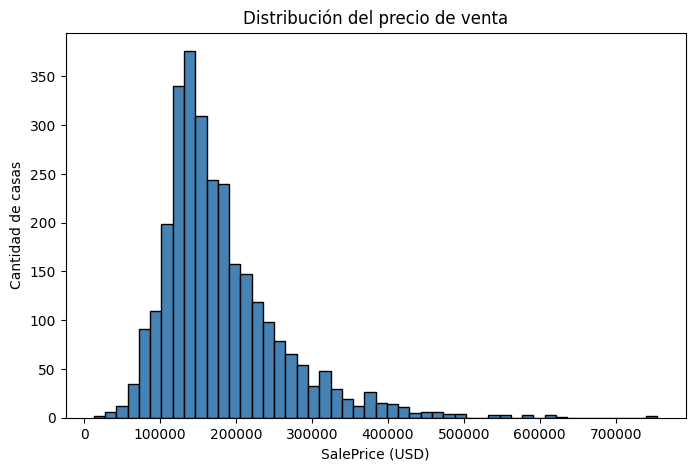

Precio promedio: $180,796
Precio mínimo:   $12,789
Precio máximo:   $755,000


In [ ]:
# CELDA 6 - ESTADÍSTICAS Y VISUALIZACIÓN

print("Estadísticas del dataset:")
display(df.describe())

# Distribución del precio (variable objetivo)
plt.figure(figsize=(8, 5))
plt.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel("SalePrice (USD)")
plt.ylabel("Cantidad de casas")
plt.title("Distribución del precio de venta")
plt.show()

print("Precio promedio: ${:,.0f}".format(df['SalePrice'].mean()))
print("Precio mínimo:   ${:,.0f}".format(df['SalePrice'].min()))
print("Precio máximo:   ${:,.0f}".format(df['SalePrice'].max()))

In [ ]:
# CELDA 7 - CONVERTIR A ARRAYS Y NORMALIZAR

X = df[features].values
y = df[target].values

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

def normalizar(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalizar(X)

print("\nMedia de cada feature:")
for i, f in enumerate(features):
    print(f"  {f}: {mu[i]:.4f}")

print("\nDesviación estándar de cada feature:")
for i, f in enumerate(features):
    print(f"  {f}: {sigma[i]:.4f}")

print("\nNormalización completada.")

Forma de X: (2930, 10)
Forma de y: (2930,)

Media de cada feature:
  Overall Qual: 6.0949
  Gr Liv Area: 1499.6904
  Total Bsmt SF: 1051.6145
  1st Flr SF: 1159.5577
  Garage Area: 472.8197
  Year Built: 1971.3563
  Full Bath: 1.5666
  TotRms AbvGrd: 6.4430
  Fireplaces: 0.5993
  Garage Cars: 1.7668

Desviación estándar de cada feature:
  Overall Qual: 1.4108
  Gr Liv Area: 505.4226
  Total Bsmt SF: 440.4647
  1st Flr SF: 391.8240
  Garage Area: 214.9731
  Year Built: 30.2402
  Full Bath: 0.5528
  TotRms AbvGrd: 1.5727
  Fireplaces: 0.6478
  Garage Cars: 0.7603

Normalización completada.


In [ ]:
# CELDA 8 - DIVISIÓN TRAIN / TEST (80/20)

split = int(len(X_norm) * 0.8)

X_train = X_norm[:split]
y_train = y[:split]

X_test = X_norm[split:]
y_test = y[split:]

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:       ", X_test.shape)
print("División 80/20 completada.")

Datos de entrenamiento: (2344, 10)
Datos de prueba:        (586, 10)
División 80/20 completada.
